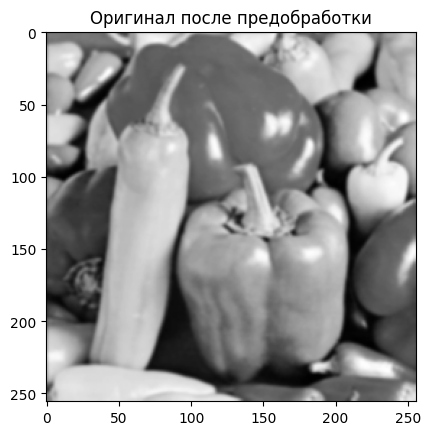

WHT-хэш: 256 бит
Гистограммный хэш: 45 бит
Общий хэш: 301 бит
Первые 32 бита общего хэша: [0 0 0 0 1 1 1 1 0 1 0 0 0 1 1 1 1 1 1 0 0 0 0 0 0 1 1 1 1 1 0 1]

Тестирование: 1000 итераций, sigma=150...
  Выполнено 100 итераций
  Выполнено 200 итераций
  Выполнено 300 итераций
  Выполнено 400 итераций
  Выполнено 500 итераций
  Выполнено 600 итераций
  Выполнено 700 итераций
  Выполнено 800 итераций
  Выполнено 900 итераций
  Выполнено 1000 итераций

Тестирование завершено за 20.58 сек.

СРЕДНИЕ NHD ПОСЛЕ 1000 ИТЕРАЦИЙ
WHT-хэш (256 бит) : 0.0655
Гистограммный хэш (45 бит): 0.3774
Общий хэш (301 бит) : 0.1121


In [187]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
from scipy.linalg import hadamard
import time
import os

# Вспомогательные функции

def preprocess(img_color, target_size=(256, 256)):
    gray = cv2.cvtColor(img_color, cv2.COLOR_BGR2GRAY)
    resized = cv2.resize(gray, target_size, interpolation=cv2.INTER_AREA)
    blurred = cv2.GaussianBlur(resized, (5, 5), 1.0)
    return blurred.astype(np.float32)

def split_blocks(img, block_size):
    h, w = img.shape
    assert h % block_size == 0 and w % block_size == 0
    blocks_h = h // block_size
    blocks_w = w // block_size
    blocks = img.reshape(blocks_h, block_size, blocks_w, block_size)
    blocks = blocks.swapaxes(1, 2).reshape(-1, block_size, block_size)
    return blocks

def get_zigzag_indices(n):
    indices = []
    for s in range(2*n-1):
        if s % 2 == 0:
            for i in range(min(s, n-1), max(-1, s-n), -1):
                j = s-i
                indices.append((i, j))
        else:
            for j in range(min(s, n-1), max(-1, s-n), -1):
                i = s-j
                indices.append((i, j))
    return indices

def wht2d(block, H):
    return H @ block @ H.T

def extract_wht_features(blocks, num_coeffs):
    n = blocks.shape[1]
    H = hadamard(n, dtype=np.float32) / np.sqrt(n)
    zigzag = get_zigzag_indices(n)
    n_blocks = blocks.shape[0]
    features = np.zeros((num_coeffs, n_blocks), dtype=np.float32)
    for i in range(n_blocks):
        coeff = wht2d(blocks[i], H)
        for k, (r, c) in enumerate(zigzag[:num_coeffs]):
            features[k, i] = coeff[r, c]
    return features

def hash_from_features(features):
    global_mean = np.mean(features)
    col_means = np.mean(features, axis=0)
    return (col_means >= global_mean).astype(np.uint8)

# Гистограммный хэш

def histogram_features(img, c=0.2, bins=10):
    mu = np.mean(img)
    low = max(0, mu*(1-c))
    high = min(255, mu*(1+c))
    bin_edges = np.linspace(low, high, bins + 1)
    hist, _ = np.histogram(img, bins=bin_edges)
    return hist.astype(np.float32)

def histogram_hash(hist):
    n = len(hist)
    bits = []
    for i in range(n):
        for j in range(i+1, n):
            bits.append(1 if hist[i] >= hist[j] else 0)
    return np.array(bits, dtype=np.uint8)

# Добавление шума

def add_gaussian_noise(img, sigma=25):
    noise = np.random.normal(0, sigma, img.shape).astype(np.float32)
    noisy = img.astype(np.float32) + noise
    return np.clip(noisy, 0, 255).astype(np.uint8)


# Основная часть

if __name__ == "__main__":
    image_path = 'peppers.tiff'
    target_size = (256, 256)
    block_size = 16
    num_coeffs = 128
    sigma = 150
    num_iterations = 1000
    c = 0.2
    num_bins = 10

    if not os.path.exists(image_path):
        raise FileNotFoundError(f"Изображение {image_path} не найдено")

    orig_color = cv2.imread(image_path)

    orig_gray = preprocess(orig_color, target_size)
    plt.imshow(orig_gray, cmap='gray')
    plt.title("Оригинал после предобработки")
    plt.show()

    # WHT
    blocks = split_blocks(orig_gray, block_size)
    wht_features = extract_wht_features(blocks, num_coeffs)
    hash_wht = hash_from_features(wht_features)

    # Гистограммы
    hist_vec = histogram_features(orig_gray, c, num_bins)
    hash_hist = histogram_hash(hist_vec)

    # Общий хэш
    full_hash = np.concatenate((hash_wht, hash_hist))

    print(f"WHT-хэш: {len(hash_wht)} бит")
    print(f"Гистограммный хэш: {len(hash_hist)} бит")
    print(f"Общий хэш: {len(full_hash)} бит")

    # Тест на устойчивость к шуму
    total_wht_diff = 0.0
    total_hist_diff = 0.0
    total_full_diff = 0.0

    print(f"\nТест: {num_iterations} итераций, sigma={sigma}...")
    start = time.perf_counter()

    for i in range(num_iterations):
        noisy_color = add_gaussian_noise(orig_color, sigma)
        noisy_gray = preprocess(noisy_color, target_size)

        # Хэши для зашумлённого
        blocks_n = split_blocks(noisy_gray, block_size)
        wht_n = hash_from_features(extract_wht_features(blocks_n, num_coeffs))
        hist_n = histogram_hash(histogram_features(noisy_gray, c, num_bins))
        full_n = np.concatenate((wht_n, hist_n))

        # Сравнение
        total_wht_diff += np.sum(hash_wht != wht_n) / len(hash_wht)
        total_hist_diff += np.sum(hash_hist != hist_n) / len(hash_hist)
        total_full_diff += np.sum(full_hash != full_n) / len(full_hash)

        if (i+1) % 100 == 0:
            print(f"  Выполнено {i+1} итераций")

    elapsed = time.perf_counter() - start
    print(f"\nТест завершен за {elapsed:.2f} сек.")

    # Средние значения
    avg_wht_nhd = total_wht_diff / num_iterations
    avg_hist_nhd = total_hist_diff / num_iterations
    avg_full_nhd = total_full_diff / num_iterations

    print("\n" + "="*60)
    print(f"СРЕДНИЕ NHD ПОСЛЕ {num_iterations} ИТЕРАЦИЙ")
    print("="*60)
    print(f"WHT-хэш ({len(hash_wht)} бит) : {avg_wht_nhd:.4f}")
    print(f"Гистограммный хэш ({len(hash_hist)} бит): {avg_hist_nhd:.4f}")
    print(f"Общий хэш ({len(full_hash)} бит) : {avg_full_nhd:.4f}")

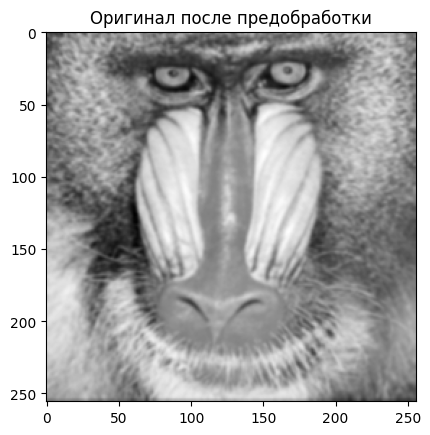

WHT-хэш: 256 бит
Гистограммный хэш: 45 бит
Общий хэш: 301 бит
Первые 32 бита общего хэша: [0 0 0 0 1 0 1 0 0 1 0 0 1 1 1 1 0 1 1 0 0 0 0 0 0 0 0 0 0 0 1 1]

Тестирование: 1000 итераций, вероятность шума=0.5...
  Выполнено 100 итераций
  Выполнено 200 итераций
  Выполнено 300 итераций
  Выполнено 400 итераций
  Выполнено 500 итераций
  Выполнено 600 итераций
  Выполнено 700 итераций
  Выполнено 800 итераций
  Выполнено 900 итераций
  Выполнено 1000 итераций

Тестирование завершено за 12.70 сек.

СРЕДНИЕ NHD ПОСЛЕ 1000 ИТЕРАЦИЙ
WHT-хэш (256 бит) : 0.1902
Гистограммный хэш (45 бит): 0.1723
Общий хэш (301 бит) : 0.1876


In [37]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
from scipy.linalg import hadamard
import time
import os

#  Вспомогательные функции

def preprocess(img_color, target_size=(256, 256)):
    gray = cv2.cvtColor(img_color, cv2.COLOR_BGR2GRAY)
    resized = cv2.resize(gray, target_size, interpolation=cv2.INTER_AREA)
    blurred = cv2.GaussianBlur(resized, (5, 5), 1.0)
    return blurred.astype(np.float32)

def split_blocks(img, block_size):
    h, w = img.shape
    assert h % block_size == 0 and w % block_size == 0
    blocks_h = h // block_size
    blocks_w = w // block_size
    blocks = img.reshape(blocks_h, block_size, blocks_w, block_size)
    blocks = blocks.swapaxes(1, 2).reshape(-1, block_size, block_size)
    return blocks

def get_zigzag_indices(n):
    indices = []
    for s in range(2*n-1):
        if s % 2 == 0:          # диагональ сверху вниз
            for i in range(min(s, n-1), max(-1, s-n), -1):
                j = s-i
                indices.append((i, j))
        else:                   # диагональ снизу вверх
            for j in range(min(s, n-1), max(-1, s-n), -1):
                i = s-j
                indices.append((i, j))
    return indices

def wht2d(block, H):
    return H @ block @ H.T

def extract_wht_features(blocks, num_coeffs):
    n = blocks.shape[1]
    H = hadamard(n, dtype=np.float32) / np.sqrt(n)
    zigzag = get_zigzag_indices(n)
    n_blocks = blocks.shape[0]
    features = np.zeros((num_coeffs, n_blocks), dtype=np.float32)
    for i in range(n_blocks):
        coeff = wht2d(blocks[i], H)
        for k, (r, c) in enumerate(zigzag[:num_coeffs]):
            features[k, i] = coeff[r, c]
    return features

def hash_from_features(features):
    global_mean = np.mean(features)
    col_means = np.mean(features, axis=0)
    return (col_means >= global_mean).astype(np.uint8)

# Гистограммный хэш

def histogram_features(img, c=0.2, bins=10):
    mu = np.mean(img)
    low = max(0, mu*(1-c))
    high = min(255, mu*(1+c))
    bin_edges = np.linspace(low, high, bins + 1)
    hist, _ = np.histogram(img, bins=bin_edges)
    return hist.astype(np.float32)

def histogram_hash(hist):
    n = len(hist)
    bits = []
    for i in range(n):
        for j in range(i+1, n):
            bits.append(1 if hist[i] >= hist[j] else 0)
    return np.array(bits, dtype=np.uint8)

#  Добавление шума

def add_salt_pepper_noise(img, prob=0.05):
    noisy = img.copy().astype(np.float32)
    random_mask = np.random.random(img.shape[:2])
    salt = random_mask < prob / 2.0
    pepper = random_mask > 1.0 - prob / 2.0
    noisy[salt] = 255
    noisy[pepper] = 0
    return np.clip(noisy, 0, 255).astype(np.uint8)

#  Основная часть

if __name__ == "__main__":
    image_path = 'mandrill.tiff'
    target_size = (256, 256)
    block_size = 16
    num_coeffs = 128
    salt_pepper_prob = 0.5
    num_iterations = 1000
    c = 0.2
    num_bins = 10

    if not os.path.exists(image_path):
        raise FileNotFoundError(f"Изображение {image_path} не найдено")

    orig_color = cv2.imread(image_path)

    orig_gray = preprocess(orig_color, target_size)
    plt.imshow(orig_gray, cmap='gray')
    plt.title("Оригинал после предобработки")
    plt.show()

    # WHT
    blocks = split_blocks(orig_gray, block_size)
    wht_features = extract_wht_features(blocks, num_coeffs)
    hash_wht = hash_from_features(wht_features)

    # Гистограммы
    hist_vec = histogram_features(orig_gray, c, num_bins)
    hash_hist = histogram_hash(hist_vec)

    # Общий хэш
    full_hash = np.concatenate((hash_wht, hash_hist))

    print(f"WHT-хэш: {len(hash_wht)} бит")
    print(f"Гистограммный хэш: {len(hash_hist)} бит")
    print(f"Общий хэш: {len(full_hash)} бит")

    # Тест на устойчивость к шуму
    total_wht_diff = 0.0
    total_hist_diff = 0.0
    total_full_diff = 0.0

    print(f"\nТест: {num_iterations} итераций, вероятность шума={salt_pepper_prob}...")
    start = time.perf_counter()

    for i in range(num_iterations):
        noisy_color = add_salt_pepper_noise(orig_color, prob=salt_pepper_prob)
        noisy_gray = preprocess(noisy_color, target_size)

        # Хэши для зашумлённого
        blocks_n = split_blocks(noisy_gray, block_size)
        wht_n = hash_from_features(extract_wht_features(blocks_n, num_coeffs))
        hist_n = histogram_hash(histogram_features(noisy_gray, c, num_bins))
        full_n = np.concatenate((wht_n, hist_n))

        # Сравнение
        total_wht_diff += np.sum(hash_wht != wht_n) / len(hash_wht)
        total_hist_diff += np.sum(hash_hist != hist_n) / len(hash_hist)
        total_full_diff += np.sum(full_hash != full_n) / len(full_hash)

        if (i+1) % 100 == 0:
            print(f"  Выполнено {i+1} итераций")

    elapsed = time.perf_counter() - start
    print(f"\nТест завершен за {elapsed:.2f} сек.")

    # Средние значения
    avg_wht_nhd = total_wht_diff / num_iterations
    avg_hist_nhd = total_hist_diff / num_iterations
    avg_full_nhd = total_full_diff / num_iterations

    print("\n" + "="*60)
    print(f"СРЕДНИЕ NHD ПОСЛЕ {num_iterations} ИТЕРАЦИЙ")
    print("="*60)
    print(f"WHT-хэш ({len(hash_wht)} бит) : {avg_wht_nhd:.4f}")
    print(f"Гистограммный хэш ({len(hash_hist)} бит): {avg_hist_nhd:.4f}")
    print(f"Общий хэш ({len(full_hash)} бит) : {avg_full_nhd:.4f}")

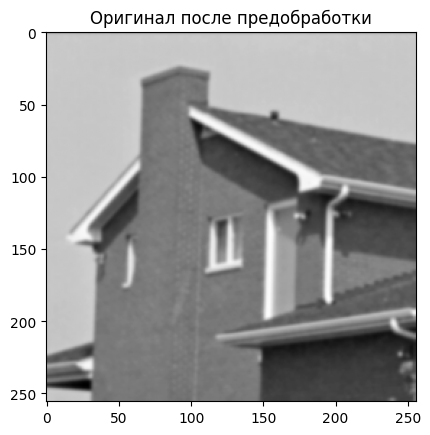

WHT-хэш: 256 бит
Гистограммный хэш: 45 бит
Общий хэш: 301 бит
Первые 32 бита общего хэша: [1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1]

Тестирование JPEG-сжатия с качеством 1...

Тестирование завершено за 0.01 сек.

РЕЗУЛЬТАТЫ ПОСЛЕ JPEG-СЖАТИЯ
WHT-хэш (256 бит) : 0.0938
Гистограммный хэш (45 бит): 0.2000
Общий хэш (301 бит) : 0.1096


In [61]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
from scipy.linalg import hadamard
import time
import os

#  Вспомогательные функции

def preprocess(img_color, target_size=(256, 256)):
    gray = cv2.cvtColor(img_color, cv2.COLOR_BGR2GRAY)
    resized = cv2.resize(gray, target_size, interpolation=cv2.INTER_AREA)
    blurred = cv2.GaussianBlur(resized, (5, 5), 1.0)
    return blurred.astype(np.float32)

def split_blocks(img, block_size):
    h, w = img.shape
    assert h % block_size == 0 and w % block_size == 0
    blocks_h = h // block_size
    blocks_w = w // block_size
    blocks = img.reshape(blocks_h, block_size, blocks_w, block_size)
    blocks = blocks.swapaxes(1, 2).reshape(-1, block_size, block_size)
    return blocks

def get_zigzag_indices(n):

    indices = []
    for s in range(2*n-1):
        if s % 2 == 0:
            for i in range(min(s, n-1), max(-1, s-n), -1):
                j = s-i
                indices.append((i, j))
        else:
            for j in range(min(s, n-1), max(-1, s-n), -1):
                i = s-j
                indices.append((i, j))
    return indices

def wht2d(block, H):
    return H @ block @ H.T

def extract_wht_features(blocks, num_coeffs):
    n = blocks.shape[1]
    H = hadamard(n, dtype=np.float32) / np.sqrt(n)
    zigzag = get_zigzag_indices(n)
    n_blocks = blocks.shape[0]
    features = np.zeros((num_coeffs, n_blocks), dtype=np.float32)
    for i in range(n_blocks):
        coeff = wht2d(blocks[i], H)
        for k, (r, c) in enumerate(zigzag[:num_coeffs]):
            features[k, i] = coeff[r, c]
    return features

def hash_from_features(features):
    global_mean = np.mean(features)
    col_means = np.mean(features, axis=0)
    return (col_means >= global_mean).astype(np.uint8)

# Гистограммный хэш

def histogram_features(img, c=0.2, bins=10):
    mu = np.mean(img)
    low = max(0, mu*(1-c))
    high = min(255, mu*(1+c))
    bin_edges = np.linspace(low, high, bins + 1)
    hist, _ = np.histogram(img, bins=bin_edges)
    return hist.astype(np.float32)

def histogram_hash(hist):
    n = len(hist)
    bits = []
    for i in range(n):
        for j in range(i+1, n):
            bits.append(1 if hist[i] >= hist[j] else 0)
    return np.array(bits, dtype=np.uint8)

# Добавление JPEG-сжатия

def apply_jpeg_compression(img, quality=50):
    encode_param = [cv2.IMWRITE_JPEG_QUALITY, quality]
    _, encoded = cv2.imencode('.jpg', img, encode_param)
    decoded = cv2.imdecode(encoded, cv2.IMREAD_COLOR)
    return decoded

# Основная часть

if __name__ == "__main__":
    image_path = 'house.tiff'
    target_size = (256, 256)
    block_size = 16
    num_coeffs = 128
    jpeg_quality = 1
    c = 0.2
    num_bins = 10

    if not os.path.exists(image_path):
        raise FileNotFoundError(f"Изображение {image_path} не найдено")

    orig_color = cv2.imread(image_path)

    orig_gray = preprocess(orig_color, target_size)
    plt.imshow(orig_gray, cmap='gray')
    plt.title("Оригинал после предобработки")
    plt.show()

    # WHT
    blocks = split_blocks(orig_gray, block_size)
    wht_features = extract_wht_features(blocks, num_coeffs)
    hash_wht = hash_from_features(wht_features)

    # Гистограммы
    hist_vec = histogram_features(orig_gray, c, num_bins)
    hash_hist = histogram_hash(hist_vec)

    # Общий хэш
    full_hash = np.concatenate((hash_wht, hash_hist))

    print(f"WHT-хэш: {len(hash_wht)} бит")
    print(f"Гистограммный хэш: {len(hash_hist)} бит")
    print(f"Общий хэш: {len(full_hash)} бит")

    # Тест на устойчивость к JPEG-сжатию
    print(f"\nТест JPEG-сжатия с качеством {jpeg_quality}...")
    start = time.perf_counter()

    compressed_color = apply_jpeg_compression(orig_color, quality=jpeg_quality)
    compressed_gray = preprocess(compressed_color, target_size)

    # Хэши для сжатого
    blocks_c = split_blocks(compressed_gray, block_size)
    wht_c = hash_from_features(extract_wht_features(blocks_c, num_coeffs))
    hist_c = histogram_hash(histogram_features(compressed_gray, c, num_bins))
    full_c = np.concatenate((wht_c, hist_c))

    # Сравнение
    wht_nhd = np.sum(hash_wht != wht_c) / len(hash_wht)
    hist_nhd = np.sum(hash_hist != hist_c) / len(hash_hist)
    full_nhd = np.sum(full_hash != full_c) / len(full_hash)

    elapsed = time.perf_counter() - start
    print(f"\nТест завершен за {elapsed:.2f} сек.")

    print("\n" + "="*60)
    print("РЕЗУЛЬТАТЫ ПОСЛЕ JPEG-СЖАТИЯ")
    print("="*60)
    print(f"WHT-хэш ({len(hash_wht)} бит) : {wht_nhd:.4f}")
    print(f"Гистограммный хэш ({len(hash_hist)} бит): {hist_nhd:.4f}")
    print(f"Общий хэш ({len(full_hash)} бит) : {full_nhd:.4f}")

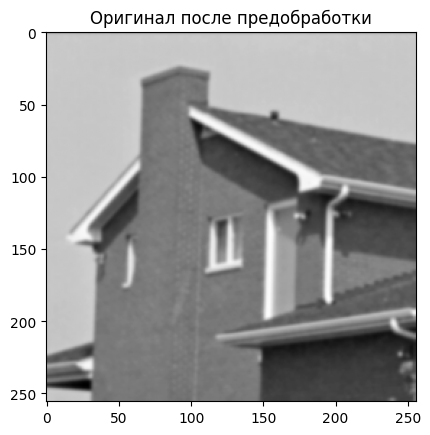

WHT-хэш: 256 бит
Гистограммный хэш: 45 бит
Общий хэш: 301 бит
Первые 32 бита общего хэша: [1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1]

Тестирование гамма-коррекции с gamma=6.0...


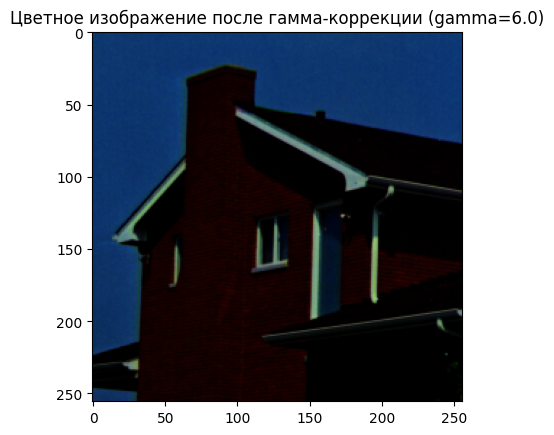

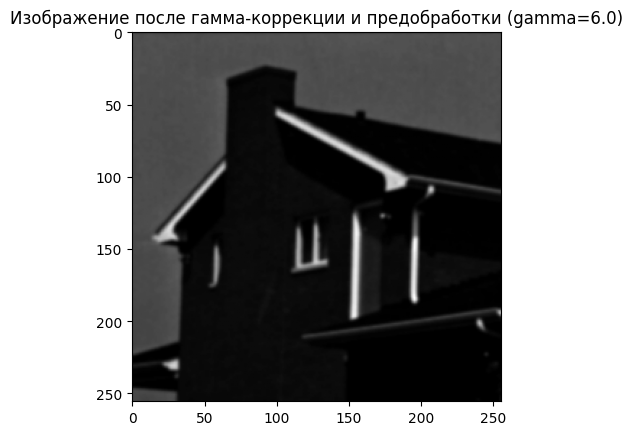


Тестирование завершено за 0.16 сек.

РЕЗУЛЬТАТЫ ПОСЛЕ ГАММА-РАЗМЫТИЯ (ГАММА-КОРРЕКЦИИ)
WHT-хэш (256 бит) : 0.0430
Гистограммный хэш (45 бит): 0.4000
Общий хэш (301 бит) : 0.0963


In [69]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
from scipy.linalg import hadamard
import time
import os

#  Вспомогательные функции

def preprocess(img_color, target_size=(256, 256)):
    gray = cv2.cvtColor(img_color, cv2.COLOR_BGR2GRAY)
    resized = cv2.resize(gray, target_size, interpolation=cv2.INTER_AREA)
    blurred = cv2.GaussianBlur(resized, (5, 5), 1.0)
    return blurred.astype(np.float32)

def split_blocks(img, block_size):

    h, w = img.shape
    assert h % block_size == 0 and w % block_size == 0
    blocks_h = h // block_size
    blocks_w = w // block_size
    blocks = img.reshape(blocks_h, block_size, blocks_w, block_size)
    blocks = blocks.swapaxes(1, 2).reshape(-1, block_size, block_size)
    return blocks

def get_zigzag_indices(n):
    indices = []
    for s in range(2*n-1):
        if s % 2 == 0:
            for i in range(min(s, n-1), max(-1, s-n), -1):
                j = s-i
                indices.append((i, j))
        else:
            for j in range(min(s, n-1), max(-1, s-n), -1):
                i = s-j
                indices.append((i, j))
    return indices

def wht2d(block, H):
    return H @ block @ H.T

def extract_wht_features(blocks, num_coeffs):
    n = blocks.shape[1]
    H = hadamard(n, dtype=np.float32) / np.sqrt(n)
    zigzag = get_zigzag_indices(n)
    n_blocks = blocks.shape[0]
    features = np.zeros((num_coeffs, n_blocks), dtype=np.float32)
    for i in range(n_blocks):
        coeff = wht2d(blocks[i], H)
        for k, (r, c) in enumerate(zigzag[:num_coeffs]):
            features[k, i] = coeff[r, c]
    return features

def hash_from_features(features):
    global_mean = np.mean(features)
    col_means = np.mean(features, axis=0)
    return (col_means >= global_mean).astype(np.uint8)

# Гистограммный хэш

def histogram_features(img, c=0.2, bins=10):
    mu = np.mean(img)
    low = max(0, mu*(1-c))
    high = min(255, mu*(1+c))
    bin_edges = np.linspace(low, high, bins + 1)
    hist, _ = np.histogram(img, bins=bin_edges)
    return hist.astype(np.float32)

def histogram_hash(hist):
    n = len(hist)
    bits = []
    for i in range(n):
        for j in range(i+1, n):
            bits.append(1 if hist[i] >= hist[j] else 0)
    return np.array(bits, dtype=np.uint8)

# Добавление гамма-коррекции

def apply_gamma_correction(img, gamma=2.2):
    img_float = img.astype(np.float32) / 255.0
    corrected = np.power(img_float, gamma)
    corrected = (corrected * 255).astype(np.uint8)
    return corrected

# Основная часть

if __name__ == "__main__":
    image_path = 'house.tiff'
    target_size = (256, 256)
    block_size = 16
    num_coeffs = 128
    gamma = 6.0
    c = 0.2
    num_bins = 10

    if not os.path.exists(image_path):
        raise FileNotFoundError(f"Изображение {image_path} не найдено")

    orig_color = cv2.imread(image_path)

    orig_gray = preprocess(orig_color, target_size)
    plt.imshow(orig_gray, cmap='gray')
    plt.title("Оригинал после предобработки")
    plt.show()

    # WHT
    blocks = split_blocks(orig_gray, block_size)
    wht_features = extract_wht_features(blocks, num_coeffs)
    hash_wht = hash_from_features(wht_features)

    # Гистограммы
    hist_vec = histogram_features(orig_gray, c, num_bins)
    hash_hist = histogram_hash(hist_vec)

    # Общий хэш
    full_hash = np.concatenate((hash_wht, hash_hist))

    print(f"WHT-хэш: {len(hash_wht)} бит")
    print(f"Гистограммный хэш: {len(hash_hist)} бит")
    print(f"Общий хэш: {len(full_hash)} бит")

    # Тест на устойчивость к гамма-коррекции
    print(f"\nТест гамма-коррекции с gamma={gamma}...")
    start = time.perf_counter()

    gamma_corrected_color = apply_gamma_correction(orig_color, gamma=gamma)

    gamma_corrected_color_rgb = cv2.cvtColor(gamma_corrected_color, cv2.COLOR_BGR2RGB)
    plt.figure()
    plt.imshow(gamma_corrected_color_rgb)
    plt.title(f"Цветное изображение после гамма-коррекции (gamma={gamma})")
    plt.show()

    gamma_corrected_gray = preprocess(gamma_corrected_color, target_size)

    plt.figure()
    plt.imshow(gamma_corrected_gray, cmap='gray')
    plt.title(f"Изображение после гамма-коррекции и предобработки (gamma={gamma})")
    plt.show()

    # Хэши для искажённого
    blocks_g = split_blocks(gamma_corrected_gray, block_size)
    wht_g = hash_from_features(extract_wht_features(blocks_g, num_coeffs))
    hist_g = histogram_hash(histogram_features(gamma_corrected_gray, c, num_bins))
    full_g = np.concatenate((wht_g, hist_g))

    # Сравнение
    wht_nhd = np.sum(hash_wht != wht_g) / len(hash_wht)
    hist_nhd = np.sum(hash_hist != hist_g) / len(hash_hist)
    full_nhd = np.sum(full_hash != full_g) / len(full_hash)

    elapsed = time.perf_counter() - start
    print(f"\nТест завершен за {elapsed:.2f} сек.")

    print("\n" + "="*60)
    print("РЕЗУЛЬТАТЫ ПОСЛЕ ГАММА-РАЗМЫТИЯ (ГАММА-КОРРЕКЦИИ)")
    print("="*60)
    print(f"WHT-хэш ({len(hash_wht)} бит) : {wht_nhd:.4f}")
    print(f"Гистограммный хэш ({len(hash_hist)} бит): {hist_nhd:.4f}")
    print(f"Общий хэш ({len(full_hash)} бит) : {full_nhd:.4f}")

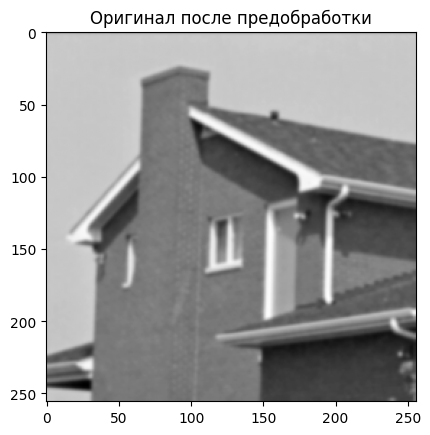

WHT-хэш: 256 бит
Гистограммный хэш: 45 бит
Общий хэш: 301 бит
Первые 32 бита общего хэша: [1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1]

Тестирование: 1000 итераций, sigma=0.5...
  Выполнено 100 итераций
  Выполнено 200 итераций
  Выполнено 300 итераций
  Выполнено 400 итераций
  Выполнено 500 итераций
  Выполнено 600 итераций
  Выполнено 700 итераций
  Выполнено 800 итераций
  Выполнено 900 итераций
  Выполнено 1000 итераций

Тестирование завершено за 10.58 сек.

СРЕДНИЕ NHD ПОСЛЕ 1000 ИТЕРАЦИЙ
WHT-хэш (256 бит) : 0.0731
Гистограммный хэш (45 бит): 0.1634
Общий хэш (301 бит) : 0.0866


In [21]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
from scipy.linalg import hadamard
import time
import os

#  Вспомогательные функции

def preprocess(img_color, target_size=(256, 256)):
    gray = cv2.cvtColor(img_color, cv2.COLOR_BGR2GRAY)
    resized = cv2.resize(gray, target_size, interpolation=cv2.INTER_AREA)
    blurred = cv2.GaussianBlur(resized, (5, 5), 1.0)
    return blurred.astype(np.float32)

def split_blocks(img, block_size):
    h, w = img.shape
    assert h % block_size == 0 and w % block_size == 0
    blocks_h = h // block_size
    blocks_w = w // block_size
    blocks = img.reshape(blocks_h, block_size, blocks_w, block_size)
    blocks = blocks.swapaxes(1, 2).reshape(-1, block_size, block_size)
    return blocks

def get_zigzag_indices(n):
    indices = []
    for s in range(2*n-1):
        if s % 2 == 0:
            for i in range(min(s, n-1), max(-1, s-n), -1):
                j = s-i
                indices.append((i, j))
        else:
            for j in range(min(s, n-1), max(-1, s-n), -1):
                i = s-j
                indices.append((i, j))
    return indices

def wht2d(block, H):
    return H @ block @ H.T

def extract_wht_features(blocks, num_coeffs):
    n = blocks.shape[1]
    H = hadamard(n, dtype=np.float32) / np.sqrt(n)
    zigzag = get_zigzag_indices(n)
    n_blocks = blocks.shape[0]
    features = np.zeros((num_coeffs, n_blocks), dtype=np.float32)
    for i in range(n_blocks):
        coeff = wht2d(blocks[i], H)
        for k, (r, c) in enumerate(zigzag[:num_coeffs]):
            features[k, i] = coeff[r, c]
    return features

def hash_from_features(features):
    global_mean = np.mean(features)
    col_means = np.mean(features, axis=0)
    return (col_means >= global_mean).astype(np.uint8)

# Гистограммный хэш

def histogram_features(img, c=0.2, bins=10):
    mu = np.mean(img)
    low = max(0, mu*(1-c))
    high = min(255, mu*(1+c))
    bin_edges = np.linspace(low, high, bins + 1)
    hist, _ = np.histogram(img, bins=bin_edges)
    return hist.astype(np.float32)

def histogram_hash(hist):
    n = len(hist)
    bits = []
    for i in range(n):
        for j in range(i+1, n):
            bits.append(1 if hist[i] >= hist[j] else 0)
    return np.array(bits, dtype=np.uint8)

#  Добавление спекл-шума

def add_speckle_noise(img, sigma=0.1):
    img_float = img.astype(np.float32)
    noise = np.random.normal(0, sigma, img.shape).astype(np.float32)
    noisy = img_float + img_float * noise
    return np.clip(noisy, 0, 255).astype(np.uint8)

# Основная часть

if __name__ == "__main__":
    image_path = 'house.tiff'
    target_size = (256, 256)
    block_size = 16
    num_coeffs = 128
    sigma = 0.5
    num_iterations = 1000
    c = 0.2
    num_bins = 10

    if not os.path.exists(image_path):
        raise FileNotFoundError(f"Изображение {image_path} не найдено")

    orig_color = cv2.imread(image_path)

    orig_gray = preprocess(orig_color, target_size)
    plt.imshow(orig_gray, cmap='gray')
    plt.title("Оригинал после предобработки")
    plt.show()

    # WHT
    blocks = split_blocks(orig_gray, block_size)
    wht_features = extract_wht_features(blocks, num_coeffs)
    hash_wht = hash_from_features(wht_features)

    # Гистограммны
    hist_vec = histogram_features(orig_gray, c, num_bins)
    hash_hist = histogram_hash(hist_vec)

    # Общий хэш
    full_hash = np.concatenate((hash_wht, hash_hist))

    print(f"WHT-хэш: {len(hash_wht)} бит")
    print(f"Гистограммный хэш: {len(hash_hist)} бит")
    print(f"Общий хэш: {len(full_hash)} бит")

    # Тест на устойчивость к шуму
    total_wht_diff = 0.0
    total_hist_diff = 0.0
    total_full_diff = 0.0

    print(f"\nТест: {num_iterations} итераций, sigma={sigma}...")
    start = time.perf_counter()

    for i in range(num_iterations):
        noisy_color = add_speckle_noise(orig_color, sigma)
        noisy_gray = preprocess(noisy_color, target_size)

        # Хэши для зашумлённого
        blocks_n = split_blocks(noisy_gray, block_size)
        wht_n = hash_from_features(extract_wht_features(blocks_n, num_coeffs))
        hist_n = histogram_hash(histogram_features(noisy_gray, c, num_bins))
        full_n = np.concatenate((wht_n, hist_n))

        # Сравнение
        total_wht_diff += np.sum(hash_wht != wht_n) / len(hash_wht)
        total_hist_diff += np.sum(hash_hist != hist_n) / len(hash_hist)
        total_full_diff += np.sum(full_hash != full_n) / len(full_hash)

        if (i+1) % 100 == 0:
            print(f"  Выполнено {i+1} итераций")

    elapsed = time.perf_counter() - start
    print(f"\nТест завершен за {elapsed:.2f} сек.")

    # Средние значения
    avg_wht_nhd = total_wht_diff / num_iterations
    avg_hist_nhd = total_hist_diff / num_iterations
    avg_full_nhd = total_full_diff / num_iterations

    print("\n" + "="*60)
    print(f"СРЕДНИЕ NHD ПОСЛЕ {num_iterations} ИТЕРАЦИЙ")
    print("="*60)
    print(f"WHT-хэш ({len(hash_wht)} бит) : {avg_wht_nhd:.4f}")
    print(f"Гистограммный хэш ({len(hash_hist)} бит): {avg_hist_nhd:.4f}")
    print(f"Общий хэш ({len(full_hash)} бит) : {avg_full_nhd:.4f}")

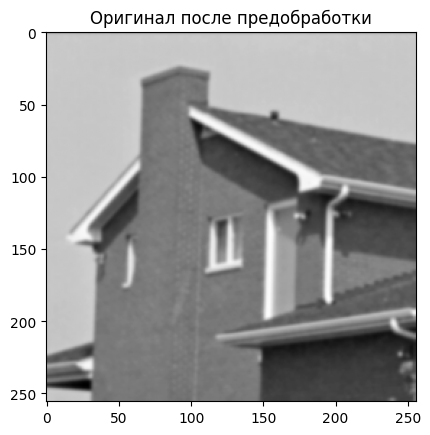

WHT-хэш: 256 бит
Гистограммный хэш: 45 бит
Общий хэш: 301 бит
Первые 32 бита общего хэша: [1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1]

Тестирование аддитивного сдвига яркости: delta=-100...


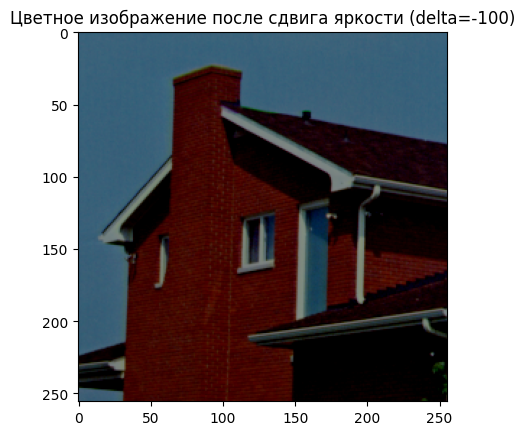

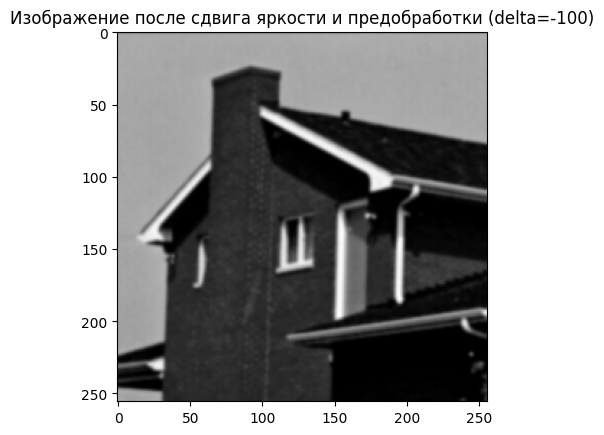


Тестирование завершено за 0.14 сек.

РЕЗУЛЬТАТЫ ПОСЛЕ АДДИТИВНОГО СДВИГА ЯРКОСТИ
WHT-хэш (256 бит) : 0.0195
Гистограммный хэш (45 бит): 0.4222
Общий хэш (301 бит) : 0.0797


In [184]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
from scipy.linalg import hadamard
import time
import os

#  Вспомогательные функции

def preprocess(img_color, target_size=(256, 256)):
    gray = cv2.cvtColor(img_color, cv2.COLOR_BGR2GRAY)
    resized = cv2.resize(gray, target_size, interpolation=cv2.INTER_AREA)
    blurred = cv2.GaussianBlur(resized, (5, 5), 1.0)
    return blurred.astype(np.float32)

def split_blocks(img, block_size):
    h, w = img.shape
    assert h % block_size == 0 and w % block_size == 0
    blocks_h = h // block_size
    blocks_w = w // block_size
    blocks = img.reshape(blocks_h, block_size, blocks_w, block_size)
    blocks = blocks.swapaxes(1, 2).reshape(-1, block_size, block_size)
    return blocks

def get_zigzag_indices(n):
    indices = []
    for s in range(2*n-1):
        if s % 2 == 0:
            for i in range(min(s, n-1), max(-1, s-n), -1):
                j = s-i
                indices.append((i, j))
        else:
            for j in range(min(s, n-1), max(-1, s-n), -1):
                i = s-j
                indices.append((i, j))
    return indices

def wht2d(block, H):
    return H @ block @ H.T

def extract_wht_features(blocks, num_coeffs):
    n = blocks.shape[1]
    H = hadamard(n, dtype=np.float32) / np.sqrt(n)
    zigzag = get_zigzag_indices(n)
    n_blocks = blocks.shape[0]
    features = np.zeros((num_coeffs, n_blocks), dtype=np.float32)
    for i in range(n_blocks):
        coeff = wht2d(blocks[i], H)
        for k, (r, c) in enumerate(zigzag[:num_coeffs]):
            features[k, i] = coeff[r, c]
    return features

def hash_from_features(features):
    global_mean = np.mean(features)
    col_means = np.mean(features, axis=0)
    return (col_means >= global_mean).astype(np.uint8)

# Гистограммный хэш

def histogram_features(img, c=0.2, bins=10):
    mu = np.mean(img)
    low = max(0, mu*(1-c))
    high = min(255, mu*(1+c))
    bin_edges = np.linspace(low, high, bins + 1)
    hist, _ = np.histogram(img, bins=bin_edges)
    return hist.astype(np.float32)

def histogram_hash(hist):
    n = len(hist)
    bits = []
    for i in range(n):
        for j in range(i+1, n):
            bits.append(1 if hist[i] >= hist[j] else 0)
    return np.array(bits, dtype=np.uint8)

# Добавление аддитивного сдвига яркости

def add_brightness_shift(img, delta):
    shifted = img.astype(np.int16) + delta
    shifted = np.clip(shifted, 0, 255)
    return shifted.astype(np.uint8)

#  Основная часть

if __name__ == "__main__":
    image_path = 'house.tiff'
    target_size = (256, 256)
    block_size = 16
    num_coeffs = 128
    brightness_delta = -100
    c = 0.2
    num_bins = 10

    if not os.path.exists(image_path):
        raise FileNotFoundError(f"Изображение {image_path} не найдено")

    orig_color = cv2.imread(image_path)

    orig_gray = preprocess(orig_color, target_size)
    plt.imshow(orig_gray, cmap='gray')
    plt.title("Оригинал после предобработки")
    plt.show()

    # WHT
    blocks = split_blocks(orig_gray, block_size)
    wht_features = extract_wht_features(blocks, num_coeffs)
    hash_wht = hash_from_features(wht_features)

    # Гистограммы
    hist_vec = histogram_features(orig_gray, c, num_bins)
    hash_hist = histogram_hash(hist_vec)

    # Общий хэш
    full_hash = np.concatenate((hash_wht, hash_hist))

    print(f"WHT-хэш: {len(hash_wht)} бит")
    print(f"Гистограммный хэш: {len(hash_hist)} бит")
    print(f"Общий хэш: {len(full_hash)} бит")

    # Тест на устойчивость к аддитивному сдвигу яркости
    print(f"\nТест аддитивного сдвига яркости: delta={brightness_delta}...")
    start = time.perf_counter()

    brightness_shifted_color = add_brightness_shift(orig_color, brightness_delta)
    
    shifted_color_rgb = cv2.cvtColor(brightness_shifted_color, cv2.COLOR_BGR2RGB)
    plt.figure()
    plt.imshow(shifted_color_rgb)
    plt.title(f"Цветное изображение после сдвига яркости (delta={brightness_delta})")
    plt.show()

    shifted_gray = preprocess(brightness_shifted_color, target_size)

    plt.figure()
    plt.imshow(shifted_gray, cmap='gray')
    plt.title(f"Изображение после сдвига яркости и предобработки (delta={brightness_delta})")
    plt.show()

    # Хэши для искажённого
    blocks_s = split_blocks(shifted_gray, block_size)
    wht_s = hash_from_features(extract_wht_features(blocks_s, num_coeffs))
    hist_s = histogram_hash(histogram_features(shifted_gray, c, num_bins))
    full_s = np.concatenate((wht_s, hist_s))

    # Сравнение
    wht_nhd = np.sum(hash_wht != wht_s) / len(hash_wht)
    hist_nhd = np.sum(hash_hist != hist_s) / len(hash_hist)
    full_nhd = np.sum(full_hash != full_s) / len(full_hash)

    elapsed = time.perf_counter() - start
    print(f"\nТест завершен за {elapsed:.2f} сек.")

    print("\n" + "="*60)
    print("РЕЗУЛЬТАТЫ ПОСЛЕ АДДИТИВНОГО СДВИГА ЯРКОСТИ")
    print("="*60)
    print(f"WHT-хэш ({len(hash_wht)} бит) : {wht_nhd:.4f}")
    print(f"Гистограммный хэш ({len(hash_hist)} бит): {hist_nhd:.4f}")
    print(f"Общий хэш ({len(full_hash)} бит) : {full_nhd:.4f}")

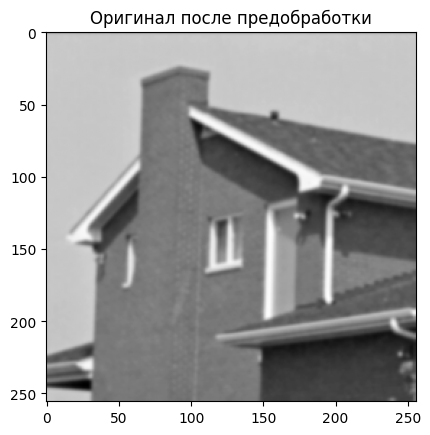

WHT-хэш: 256 бит
Гистограммный хэш: 45 бит
Общий хэш: 301 бит
Первые 32 бита общего хэша: [1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1]

Тестирование обрезания: сторона='right', pixels=10...


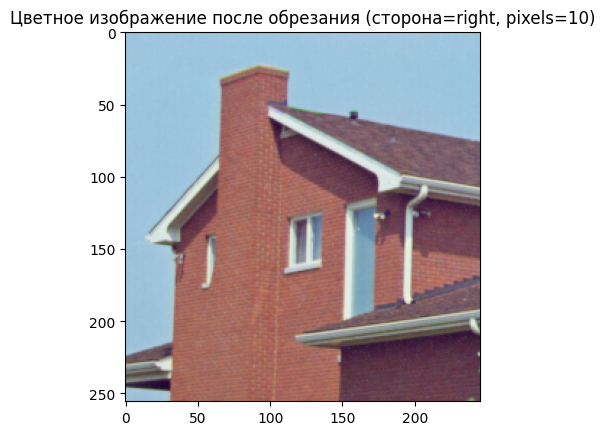

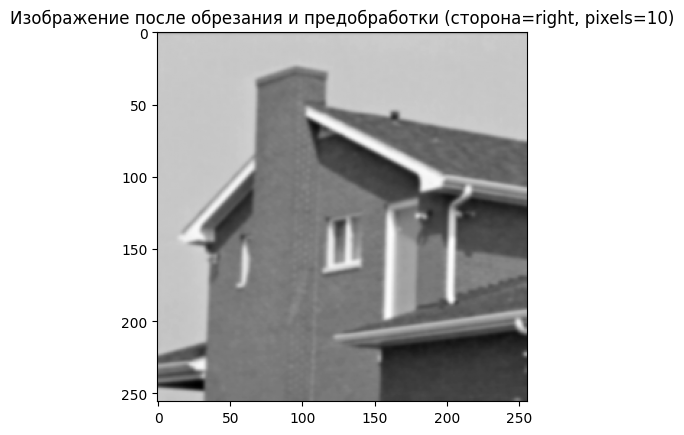


Тестирование завершено за 0.15 сек.

РЕЗУЛЬТАТЫ ПОСЛЕ ОБРЕЗАНИЯ ИЗОБРАЖЕНИЯ (CROPPING)
WHT-хэш (256 бит) : 0.0859
Гистограммный хэш (45 бит): 0.1333
Общий хэш (301 бит) : 0.0930


In [158]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
from scipy.linalg import hadamard
import time
import os

#  Вспомогательные функции

def preprocess(img_color, target_size=(256, 256)):
    gray = cv2.cvtColor(img_color, cv2.COLOR_BGR2GRAY)
    resized = cv2.resize(gray, target_size, interpolation=cv2.INTER_AREA)
    blurred = cv2.GaussianBlur(resized, (5, 5), 1.0)
    return blurred.astype(np.float32)

def split_blocks(img, block_size):
    h, w = img.shape
    assert h % block_size == 0 and w % block_size == 0
    blocks_h = h // block_size
    blocks_w = w // block_size
    blocks = img.reshape(blocks_h, block_size, blocks_w, block_size)
    blocks = blocks.swapaxes(1, 2).reshape(-1, block_size, block_size)
    return blocks

def get_zigzag_indices(n):
    indices = []
    for s in range(2*n-1):
        if s % 2 == 0:
            for i in range(min(s, n-1), max(-1, s-n), -1):
                j = s-i
                indices.append((i, j))
        else:
            for j in range(min(s, n-1), max(-1, s-n), -1):
                i = s-j
                indices.append((i, j))
    return indices

def wht2d(block, H):
    return H @ block @ H.T

def extract_wht_features(blocks, num_coeffs):
    n = blocks.shape[1]
    H = hadamard(n, dtype=np.float32) / np.sqrt(n)
    zigzag = get_zigzag_indices(n)
    n_blocks = blocks.shape[0]
    features = np.zeros((num_coeffs, n_blocks), dtype=np.float32)
    for i in range(n_blocks):
        coeff = wht2d(blocks[i], H)
        for k, (r, c) in enumerate(zigzag[:num_coeffs]):
            features[k, i] = coeff[r, c]
    return features

def hash_from_features(features):
    global_mean = np.mean(features)
    col_means = np.mean(features, axis=0)
    return (col_means >= global_mean).astype(np.uint8)

# Гистограммный хэш

def histogram_features(img, c=0.2, bins=10):
    mu = np.mean(img)
    low = max(0, mu*(1-c))
    high = min(255, mu*(1+c))
    bin_edges = np.linspace(low, high, bins + 1)
    hist, _ = np.histogram(img, bins=bin_edges)
    return hist.astype(np.float32)

def histogram_hash(hist):
    n = len(hist)
    bits = []
    for i in range(n):
        for j in range(i+1, n):
            bits.append(1 if hist[i] >= hist[j] else 0)
    return np.array(bits, dtype=np.uint8)

# Добавление обрезки

def crop_image(img, side, pixels):
    h, w = img.shape[:2]
    if side == 'left':
        return img[:, pixels:w, :]
    elif side == 'right':
        return img[:, :w-pixels, :]
    elif side == 'top':
        return img[pixels:h, :, :]
    elif side == 'bottom':
        return img[:h-pixels, :, :]
    else:
        raise ValueError("side must be 'left', 'right', 'top' or 'bottom'")


# Основная часть

if __name__ == "__main__":
    image_path = 'house.tiff'
    target_size = (256, 256)
    block_size = 16
    num_coeffs = 128
    crop_side = 'right'
    crop_pixels = 10
    c = 0.2
    num_bins = 10

    if not os.path.exists(image_path):
        raise FileNotFoundError(f"Изображение {image_path} не найдено")

    orig_color = cv2.imread(image_path)

    orig_gray = preprocess(orig_color, target_size)
    plt.imshow(orig_gray, cmap='gray')
    plt.title("Оригинал после предобработки")
    plt.show()

    # WHT
    blocks = split_blocks(orig_gray, block_size)
    wht_features = extract_wht_features(blocks, num_coeffs)
    hash_wht = hash_from_features(wht_features)

    # Гистограммы
    hist_vec = histogram_features(orig_gray, c, num_bins)
    hash_hist = histogram_hash(hist_vec)

    # Общий хэш
    full_hash = np.concatenate((hash_wht, hash_hist))

    print(f"WHT-хэш: {len(hash_wht)} бит")
    print(f"Гистограммный хэш: {len(hash_hist)} бит")
    print(f"Общий хэш: {len(full_hash)} бит")

    # Тест на устойчивость к обрезке
    print(f"\nТестирование обрезания: сторона='{crop_side}', pixels={crop_pixels}...")
    start = time.perf_counter()

    cropped_color = crop_image(orig_color, crop_side, crop_pixels)

    cropped_color_rgb = cv2.cvtColor(cropped_color, cv2.COLOR_BGR2RGB)
    plt.figure()
    plt.imshow(cropped_color_rgb)
    plt.title(f"Цветное изображение после обрезания (сторона={crop_side}, pixels={crop_pixels})")
    plt.show()

    cropped_gray = preprocess(cropped_color, target_size)

    plt.figure()
    plt.imshow(cropped_gray, cmap='gray')
    plt.title(f"Изображение после обрезания и предобработки (сторона={crop_side}, pixels={crop_pixels})")
    plt.show()

    # Хэши для искажённого
    blocks_c = split_blocks(cropped_gray, block_size)
    wht_c = hash_from_features(extract_wht_features(blocks_c, num_coeffs))
    hist_c = histogram_hash(histogram_features(cropped_gray, c, num_bins))
    full_c = np.concatenate((wht_c, hist_c))

    # Сравнение
    wht_nhd = np.sum(hash_wht != wht_c) / len(hash_wht)
    hist_nhd = np.sum(hash_hist != hist_c) / len(hash_hist)
    full_nhd = np.sum(full_hash != full_c) / len(full_hash)

    elapsed = time.perf_counter() - start
    print(f"\nТест завершен за {elapsed:.2f} сек.")

    print("\n" + "="*60)
    print("РЕЗУЛЬТАТЫ ПОСЛЕ ОБРЕЗАНИЯ ИЗОБРАЖЕНИЯ (CROPPING)")
    print("="*60)
    print(f"WHT-хэш ({len(hash_wht)} бит) : {wht_nhd:.4f}")
    print(f"Гистограммный хэш ({len(hash_hist)} бит): {hist_nhd:.4f}")
    print(f"Общий хэш ({len(full_hash)} бит) : {full_nhd:.4f}")